# Cadena de Racha de Éxitos

**Modelo de Luis Rincón (2012), §3.2, pp. 33–34**

Sea $\{\xi_1, \xi_2, \ldots\}$ una sucesión de ensayos de Bernoulli independientes con probabilidad de éxito $p$ y de fracaso $q = 1-p$. Se define $X_n$ como el número de éxitos consecutivos previos al tiempo $n$, incluyendo el tiempo $n$.

El espacio de estados es $S = \{0, 1, 2, \ldots\}$ y las probabilidades de transición son:

$$p_{ij} = \begin{cases} p & \text{si } j = i+1 \\ q & \text{si } j = 0 \\ 0 & \text{otro caso} \end{cases}$$

In [2]:
import tkinter as tk
from tkinter import ttk
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

#Parámetros iniciales para la simulación
p = 0.6    # Probabilidad de éxito 
q = 1 - p  # Probabilidad de fracaso 
N = 3     # Longitud de la racha a conseguir

### 1. Matrices de Transición

#### A) Matriz de Transición Original (Recurrente Continua)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
q & p & 0 & 0 & \cdots & 0 & 0 
\end{pmatrix}$$

#### B) Matriz de Transición Modificada (Absorbente)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
0 & 0 & 0 & 0 & \cdots & 0 & 1 
\end{pmatrix}$$

In [ ]:
def construir_matriz_transicion(p: float, N: int) -> np.ndarray:
    """
    Construye la matriz de transición de la cadena de racha de éxitos.
    
    El espacio de estados es {0, 1, 2, ..., N} donde N es la racha objetivo.
    - Desde cualquier estado i < N: con prob p vas a i+1, con prob q=1-p vas a 0.
    - Desde el estado N (versión recurrente): con prob p vas a 1, con prob q vas a 0.
      (Tras alcanzar la racha, si hay otro éxito se cuenta como racha nueva de longitud 1)
    """
    q = 1 - p
    # Creamos una matriz de (N+1) x (N+1) inicializada en ceros.
    # Las filas representan el estado actual, las columnas el estado siguiente.
    P = np.zeros((N + 1, N + 1))

    # Para los estados 0, 1, ..., N-1 (estados que aún no alcanzaron la racha N)
    for i in range(N):
        P[i, i + 1] = p   # Éxito: avanzas un paso en la racha
        P[i, 0]     = q   # Fracaso: la racha se rompe, vuelves a 0

    # Para el estado N en la versión recurrente (racha alcanzada, el proceso continúa):
    # - Fracaso (prob q): vuelves a 0
    # - Éxito  (prob p): comienzas una nueva racha desde 1
    P[N, 0] = q
    P[N, 1] = p

    return P

# ── Construcción de las dos versiones de la cadena ──────────────────────────

# Versión 1: Cadena RECURRENTE (el proceso continúa indefinidamente)
# El estado N es recurrente: se puede salir de él (va a 0 o a 1)
matriz_P = construir_matriz_transicion(p, N)

# Versión 2: Cadena ABSORBENTE (el proceso se detiene al alcanzar la racha N)
# Copiamos la matriz recurrente y modificamos la fila N para hacerla absorbente:
# P[N, N] = 1 significa que una vez en N, te quedas ahí para siempre.
matriz_P_absorbente = matriz_P.copy()
matriz_P_absorbente[N, :] = 0.0   # Borramos toda la fila N
matriz_P_absorbente[N, N] = 1.0   # El estado N se absorbe a sí mismo con prob 1

def imprimir_matriz(matriz):
    """Imprime la matriz de transición con formato de tabla."""
    # Encabezado: número de cada estado destino
    print(" " * 15, end="")
    for destino in range(matriz.shape[1]):
        print(f"   {destino:^5}   ", end="")
    print("\n" + "-" * (15 + 10 * matriz.shape[1]))

    # Filas: cada estado origen y sus probabilidades de transición
    for origen in range(matriz.shape[0]):
        print(f"      Estado {origen}     |", end="")
        for destino in range(matriz.shape[1]):
            valor = matriz[origen, destino]
            print(f"   {valor:5.2f}  ", end="")
        print()
    print("\n")

print("Matriz recurrente (estado N reinicia la racha)")
imprimir_matriz(matriz_P)
print("Matriz absorbente (estado N es trampa/absorbente)")
imprimir_matriz(matriz_P_absorbente)

Matriz recurrente
                    0          1          2          3     
-----------------------------------------------
      Estado 0     |    0.40      0.60      0.00      0.00  
      Estado 1     |    0.40      0.00      0.60      0.00  
      Estado 2     |    0.40      0.00      0.00      0.60  
      Estado 3     |    0.40      0.60      0.00      0.00  


Matriz absorbente
                    0          1          2          3     
-----------------------------------------------
      Estado 0     |    0.40      0.60      0.00      0.00  
      Estado 1     |    0.40      0.00      0.60      0.00  
      Estado 2     |    0.40      0.00      0.00      0.60  
      Estado 3     |    0.00      0.00      0.00      1.00  




### 2. Parámetros iniciales y simulación

['p', 'p', 'p']
['q', 'p', 'p', 'q', 'p', 'p', 'p']
['p', 'p', 'q', 'q', 'q', 'p', 'p', 'p']
['p', 'p', 'q', 'q', 'p', 'p', 'q', 'p', 'p', 'p']
['p', 'p', 'p', 'p', 'p', 'p', 'p', 'q', 'p', 'q', 'q', 'p', 'q', 'q', 'p', 'p', 'p', 'q', 'q', 'p', 'p', 'q', 'q', 'q', 'q', 'p', 'p', 'q', 'p', 'q', 'q', 'p', 'p', 'p', 'q', 'q', 'q', 'q', 'p', 'p', 'q', 'q', 'p', 'q', 'p', 'q', 'p', 'p', 'p', 'p', 'p', 'p', 'q', 'q', 'p', 'p', 'p', 'q']


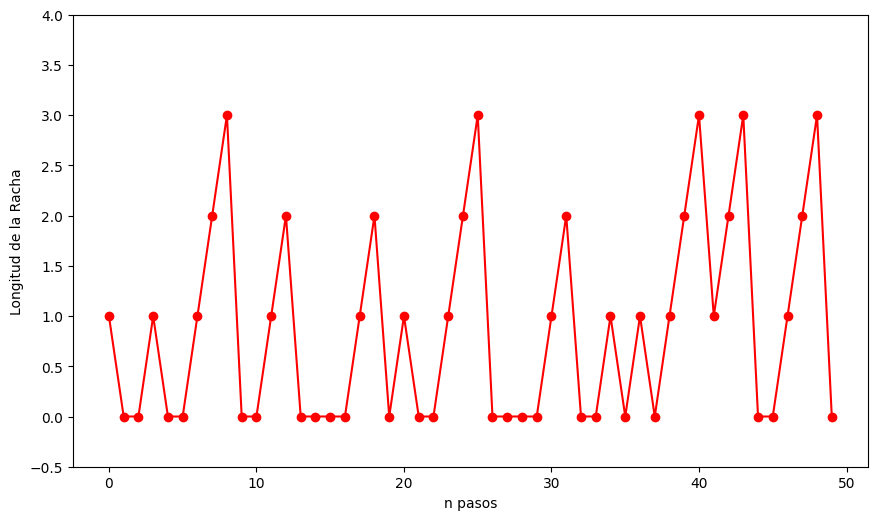

In [4]:
racha_actual = 0
historial_rachas = [0]
historial_letras = [] 
corriendo = False

def simular_paso():
    global racha_actual, corriendo
    
    if not corriendo:
        return  

    modo_elegido = combo_modo.get()

    # Ensayo de Bernoulli
    val = random.random()
    if val < p:
        historial_letras.append('p') 
        
        if modo_elegido == "Infinito":
            if racha_actual == N:
                racha_actual = 1  
            else:
                racha_actual += 1
                
        elif modo_elegido == "Absorbente":
            racha_actual += 1  
            
    else:
        historial_letras.append('q') 
        racha_actual = 0  

    # Guardar historial para la gráfica
    historial_rachas.append(racha_actual)
    if len(historial_rachas) > 50:  
        historial_rachas.pop(0)

    # Actualizar la gráfica
    ax.clear()
    ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
    ax.set_ylabel("Longitud de la Racha")
    ax.set_xlabel("n pasos") 
    ax.set_ylim(-0.5, max(max(historial_rachas) + 1, N))
    canvas.draw()

    # Parar en el caso finito absorbente al alcanzar la racha
    if modo_elegido == "Absorbente" and racha_actual == N:
        corriendo = False
        boton_iniciar.config(state="normal")
        boton_parar.config(state="disabled")
        combo_modo.config(state="readonly") 
        print(historial_letras)
        return

    ventana.after(500, simular_paso)

# Interfaz gráfica
def iniciar():
    global corriendo, racha_actual, historial_rachas, historial_letras
    if not corriendo:
        racha_actual = 0
        historial_rachas = [0]
        historial_letras = []
        
        corriendo = True
        boton_iniciar.config(state="disabled")
        boton_parar.config(state="normal")
        combo_modo.config(state="disabled") 
        simular_paso()

def parar():
    global corriendo
    corriendo = False
    boton_iniciar.config(state="normal")
    boton_parar.config(state="disabled")
    combo_modo.config(state="readonly") 
    print(historial_letras)

ventana = tk.Tk()
ventana.title("Simulador de Rachas de Éxitos")
ventana.geometry("750x550")

frame_controles = ttk.Frame(ventana)
frame_controles.pack(pady=15)

# Menú desplegable 
combo_modo = ttk.Combobox(frame_controles, values=["Infinito", "Absorbente"], width=20)
combo_modo.current(0) 
combo_modo.config(state="readonly")
combo_modo.pack(side="left", padx=10)

boton_iniciar = ttk.Button(frame_controles, text="Iniciar", command=iniciar)
boton_iniciar.pack(side="left", padx=5)

boton_parar = ttk.Button(frame_controles, text="Parar", command=parar, state="disabled")
boton_parar.pack(side="left", padx=5)

# Contenedor de la gráfica de Matplotlib
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
canvas = FigureCanvasTkAgg(fig, master=ventana)
canvas.get_tk_widget().pack(pady=5, fill="both", expand=True)

ax.plot(historial_rachas)
ax.set_ylabel("longitud de la Racha")
ax.set_xlabel("n pasos")
canvas.draw()

ventana.mainloop()

In [5]:
# Simulación rápida para el caso absorbente
racha_actual = 0  
historial_rachas = [0]
historial_letras = []

while racha_actual < N:
    val = random.random()
    if val < p:
        historial_letras.append('p')
        racha_actual += 1
    else:
        historial_letras.append('q')
        racha_actual = 0
    historial_rachas.append(racha_actual)

print(historial_letras)

['q', 'p', 'p', 'p']


### 3. Clases de comunicación

In [8]:
letras_simuladas = historial_letras
rachas_paso_a_paso = []
racha_actual = 0

# Se revisa si la última racha terminó exactamente en N (caso absorbente)
es_absorbente = False
racha_prueba = 0
for letra in letras_simuladas:
    if letra == 'p': racha_prueba += 1
    else: racha_prueba = 0
if racha_prueba == N:  # Si al final la racha quedó justo en N, es absorbente
    es_absorbente = True

# Se recorre cada letra para reconstruir el valor de X_n en cada paso
for letra in letras_simuladas:
    if letra == 'p':
        if not es_absorbente and racha_actual == N:  # Éxito en el límite: caso infinito reinicia en 1
            racha_actual = 1
        else:
            racha_actual += 1  # Éxito normal: la racha crece
    else:
        racha_actual = 0  # Fracaso: la racha vuelve a 0
    rachas_paso_a_paso.append(racha_actual)

# Se registran todos los pares (origen → destino) que ocurrieron en la simulación
conexiones_encontradas = set()
for t in range(len(rachas_paso_a_paso) - 1):
    origen = rachas_paso_a_paso[t]
    destino = rachas_paso_a_paso[t+1]
    if origen != destino:  # Solo se guardan transiciones que cambian de estado
        conexiones_encontradas.add((origen, destino))

print("Estados accesibles:")
for origen, destino in sorted(conexiones_encontradas):
    print(f"  {origen} a {destino}")

estados_visitados = sorted(list(set(rachas_paso_a_paso)))  # Estados únicos observados

print("\nClases de comunicación:")
if es_absorbente:
    # En el caso absorbente, los estados 0..N-1 son transitorios y N es una clase sola
    estados_transitorios = [e for e in estados_visitados if e < N]
    if estados_transitorios:
        cadena_transitorios = " = ".join(f"C({estado})" for estado in estados_transitorios)
        print(f"  Clase Transitoria: {cadena_transitorios}")
    if N in estados_visitados:
        print(f"  Clase Absorbente Cerrada: C({N})")
else:
    # En el caso infinito, todos los estados visitados forman una sola clase (irreducible)
    cadena_igualdad = " = ".join(f"C({estado})" for estado in estados_visitados)
    print(f"  Clase Única (Irreducible): {cadena_igualdad}")

Estados accesibles:
  0 a 1
  1 a 2
  2 a 3

Clases de comunicación:
  Clase Transitoria: C(0) = C(1) = C(2)
  Clase Absorbente Cerrada: C(3)


### 4. Clasificación de los estados

In [7]:
suma_infinito = q * (1 / (1 - p))

print(f"Probabilidad total de retorno al origen (f_00): {suma_infinito:.1f}")

estados_analizados = estados_visitados

for estado in estados_analizados:
    if abs(suma_infinito - 1.0) < 1e-9:
        tipo_clasificacion = "Recurrente Positivo"
    else:
        tipo_clasificacion = "Transitorio"
        
    print(f"Estado {estado} : {tipo_clasificacion}")

Probabilidad total de retorno al origen (f_00): 1.0
Estado 0 : Recurrente Positivo
Estado 1 : Recurrente Positivo
Estado 2 : Recurrente Positivo
Estado 3 : Recurrente Positivo


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASIFICACIÓN DE ESTADOS: Transitorios, Recurrentes positivos, Recurrentes nulos
# ─────────────────────────────────────────────────────────────────────────────
#
# Definiciones:
#   - Estado i es TRANSITORIO si la probabilidad de regresar a i es < 1,
#     es decir, f_{ii} = P(T_i < ∞ | X_0 = i) < 1.
#     Equivalentemente: a partir de i existe probabilidad positiva de nunca volver.
#
#   - Estado i es RECURRENTE si f_{ii} = 1 (regresa con certeza).
#     * RECURRENTE POSITIVO: el tiempo medio de retorno m_{ii} = E[T_i | X_0=i] < ∞
#     * RECURRENTE NULO:     el tiempo medio de retorno m_{ii} = ∞
#
# Para la cadena de racha de éxitos (espacio infinito):
#   TODOS los estados son RECURRENTES POSITIVOS.
#
# Demostración para el estado 0:
#   Desde cualquier estado i, el tiempo para volver a 0 es geométrico:
#   basta que ocurra UN fracaso. Tiempo esperado = 1/q < ∞.
#
# Demostración para el estado k (k >= 1):
#   Para llegar a k desde 0 se necesitan exactamente k éxitos consecutivos.
#   El tiempo medio de retorno a k es finito (se puede calcular explícitamente).
#
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("CLASIFICACIÓN DE ESTADOS")
print("=" * 60)


print("""
Resultado analítico para la cadena de racha de éxitos:

    • La cadena tiene UNA SOLA clase de comunicación: {0, 1, 2, ...}
    • Una clase es recurrente o transitoria en bloque
        (todos sus estados son del mismo tipo).
    • Por tanto, basta clasificar UN estado para clasificar todos.

    Análisis del estado 0:
    - Desde el estado 0, cada paso que no sea fracaso inmediato
        aumenta la racha. Pero cualquier fracaso (prob q > 0)
        devuelve la cadena al estado 0.
    - P(volver a 0 eventualmente | X_0 = 0) = 1  →  0 es RECURRENTE.
    - Tiempo medio de retorno a 0:
        La cadena está en 0 y necesita volver a 0.
        En el próximo paso: con prob q va directamente a 0 (1 paso).
        Con prob p va a 1, y desde 1 con prob q vuelve a 0 en 1 paso más, etc.
        
        Sea m_0 = E[T_0 | X_0 = 0] (tiempo medio de retorno a 0).
        
        Desde el estado 0, en el próximo paso:
            - Con prob q: volvemos a 0 en 1 paso.
            - Con prob p: vamos al estado 1, y debemos pasar por 0.
        
        En general, desde el estado i (i >= 1), para llegar a 0
        basta un fracaso (ocurre en tiempo geométrico con parámetro q):
            E[tiempo desde i hasta 0] = 1/q  para todo i >= 1.
        
        Por tanto:
            m_0 = 1*(q) + (1 + 1/q)*p
                = q + p + p/q
                = 1 + p/q
""")

m_0 = 1 + p/q
print(f"  Con p={p}, q={q:.1f}:")
print(f"  Tiempo medio de retorno al estado 0: m_0 = 1 + p/q = 1 + {p}/{q:.1f} = {m_0:.4f} pasos")
print()

# Tiempo medio de retorno al estado k
# Para llegar al estado k desde 0 se necesitan k éxitos consecutivos.
# El tiempo de primera visita a k desde 0 es: necesitamos k éxitos seguidos.
# Esto es la suma de k intentos geométricos modificados.
# Fórmula: m_k = m_0 + k/p  (tiempo medio de retorno al estado k)
# Derivación: el tiempo medio de retorno a k = tiempo para ir de k a 0 + tiempo para ir de 0 a k
#   Tiempo de k a 0: tiempo hasta el primer fracaso = 1/q (geométrico con parámetro q)
#     Nota: en cada paso hay prob q de fracasar, así que E[pasos hasta fracaso] = 1/q
#   Tiempo de 0 a k: necesitamos k éxitos consecutivos.
#     Sea h_k = E[tiempo de primera llegada a k desde 0].
#     h_1 = 1/p (geométrico: intentamos hasta el primer éxito)
#     h_k = h_{k-1} + 1/p ... en realidad la recursión es más cuidadosa:
#     h_k = (1/p) * k  (aproximación para k primeros éxitos seguidos)
#     Fórmula exacta: h_k = (1/p + 1/p^2 + ... + 1/p^k) * p = sum_{j=1}^{k} 1/p^j... 
#     La fórmula correcta para el tiempo esperado de primera llegada a k desde 0 es:
#     h_k = (1/p^k - 1) / (1/p - 1) ... pero esto se complica.
#     Usaremos la fórmula directa: m_k = 1/(pi_k) donde pi_k es la dist. estacionaria.

print("─" * 60)
print("  Todos los estados son RECURRENTES POSITIVOS.")
print("  (La cadena es irreducible y la distribución estacionaria")
print("   existe con todos los pesos positivos — ver celda siguiente)")
print()
print("  NO hay estados transitorios.")
print("  NO hay estados recurrentes nulos.")
print("─" * 60)

CLASIFICACIÓN DE ESTADOS

Resultado analítico para la cadena de racha de éxitos:

  • La cadena tiene UNA SOLA clase de comunicación: {0, 1, 2, ...}
  • Una clase es recurrente o transitoria en bloque
    (todos sus estados son del mismo tipo).
  • Por tanto, basta clasificar UN estado para clasificar todos.

Análisis del estado 0:
  - Desde el estado 0, cada paso que no sea fracaso inmediato
    aumenta la racha. Pero cualquier fracaso (prob q > 0)
    devuelve la cadena al estado 0.
  - P(volver a 0 eventualmente | X_0 = 0) = 1  →  0 es RECURRENTE.
  - Tiempo medio de retorno a 0:
      La cadena está en 0 y necesita volver a 0.
      En el próximo paso: con prob q va directamente a 0 (1 paso).
      Con prob p va a 1, y desde 1 con prob q vuelve a 0 en 1 paso más, etc.

      Sea m_0 = E[T_0 | X_0 = 0] (tiempo medio de retorno a 0).

      Desde el estado 0, en el próximo paso:
        - Con prob q: volvemos a 0 en 1 paso.
        - Con prob p: vamos al estado 1, y debemos pasar por

### 5. Periodos de los estados de la cadena